<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_2_1_1_LogReg_Intro_w_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to logistic regression with titanic

Author: Brad Sheese


---

# Introduction to Classification - Logistic Regression

This notebook introduces 'classification' through logistic regression. This is a form of supervised learning because we use a dataset where the labels (the outcome we want to predict) are already known. By the end of this exercise, you should be able to train a model to predict a discrete category based on input data.

Before starting, you should be comfortable with simple linear regression. If you need a refresher, please review those exercises first.


---
## Goals of Classification with logistic regression
To 'classify' means to take a specific case in our dataset and assign it to a discrete category. For example, imagine a dataset of fruits with physical dimensions (length, width, height) and labels (apple or banana). We want to determine if these dimensions can predict the fruit's classification. Perhaps length is a reliable way to differentiate an apple from a banana.

This differs from linear regression, where we predict continuous outcomes (like price or temperature). In logistic regression, we want to discover which parameters—often called features—help us differentiate between categories.


---
## Assumptions of Binary logistic regression
When our outcome of interest has only two categories (e.g., survived or deceased), we use binary logistic regression. This model relies on several key assumptions to ensure accuracy.



### Assumption 1: Binary Outcome
The dependent variable must be binary. In our data, we represent these outcomes with 0 and 1 (e.g., 0 for deceased, 1 for survived).



### Assumption 2: Low Levels of multicollinearity
The features (independent variables) should not be too strongly related to one another. If two features are perfectly correlated—for instance, measuring length in both inches and centimeters—including both would make the model difficult to interpret and lead to inaccurate parameter weights.

A common rule of thumb is that correlations between predictors should stay below .80. This can be tested more formally using the variance inflation factor (vif).



### Assumption 3: Independent Errors
The observations must be independent of one another. For example, our data should represent unique individuals, not the same person assessed repeatedly over time. If errors are correlated due to clustering or repeated assessments, the standard logistic regression model will not function correctly.



### Assumption 4: linear Relationship Between Predictors and logit of Outcome
While logistic regression is used for non-linear classification, it assumes a linear relationship between the continuous predictors and the logit (log-odds) of the outcome.



### Assumption 5: homoscedasticity
The model assumes that the variance of the error terms is constant across all levels of the independent variables. If the spread of your data varies wildly at different points, it may impact the reliability of the model.


---
### Additional Considerations:

* outliers: Outliers can disproportionately influence parameters and distort your results. It is essential to visualize your data to spot these before training your model.
* sample size: Larger samples provide more stable results. Small datasets may lead to violations of the model's assumptions and overfitting.






In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set visualization style
sns.set_theme(style="whitegrid")

## logistic regression Exercise: Predicting Survival on the titanic
We've explored the titanic dataset through descriptive statistics and visualizations. Logistic regression allows us to go a step further and formally quantify the contribution of each predictor to a passenger's likelihood of survival.

In [3]:
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_titanic.csv'
df = pd.read_csv(url)

# Standardize column names
df.columns = df.columns.str.lower().str.replace(' aboard', '', regex=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   survived          887 non-null    int64  
 1   pclass            887 non-null    int64  
 2   name              887 non-null    object 
 3   sex               887 non-null    object 
 4   age               887 non-null    float64
 5   siblings/spouses  887 non-null    int64  
 6   parents/children  887 non-null    int64  
 7   fare              887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


## Cleaning and Preparing the dataset

### Check for Missing Values
It is always good practice to check for missing values. This version of the titanic data is clean, but you should always verify.

In [4]:
df.isna().sum()

,0
survived,0
pclass,0
name,0
sex,0
age,0
siblings/spouses,0
parents/children,0
fare,0


### Encoding and Transforming features
Machine learning models require numerical input. We need to convert categorical text (like sex) into numbers and handle skewed distributions (like fare).

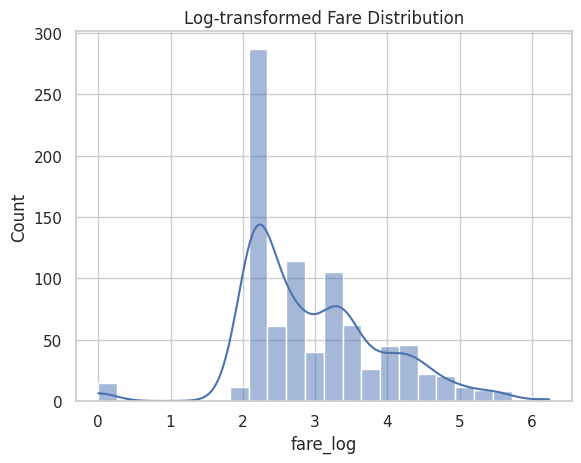

In [5]:
# Create binary indicators for family presence
df['sibspouse'] = (df['siblings/spouses'] > 0).astype(int)
df['parentchild'] = (df['parents/children'] > 0).astype(int)

# Encode sex: male=0, female=1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Handle the skewed distribution of fares by applying a log transformation
# We add 1 (log1p) to avoid taking the log of zero
df['fare_log'] = np.log1p(df['fare'])

sns.histplot(df['fare_log'], kde=True)
plt.title('Log-transformed Fare Distribution')
plt.show()

### one-hot encoding class
Since passenger class (1, 2, or 3) is categorical, we should treat it as such rather than a continuous number. We use 'dummy coding' to create a separate column for each class.

In [6]:
df = pd.get_dummies(df, columns=['pclass'], prefix='pclass')
df.head()

,survived,name,sex,age,siblings/spouses,parents/children,fare,sibspouse,parentchild,fare_log,pclass_1,pclass_2,pclass_3
0,0,Mr. Owen Harris Braund,0,22.0,1,0,7.2500,1,0,2.110213,False,False,True
1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,1,38.0,1,0,71.2833,1,0,4.280593,True,False,False
2,1,Miss. Laina Heikkinen,1,26.0,0,0,7.9250,0,0,2.188856,False,False,True
3,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,1,35.0,1,0,53.1000,1,0,3.990834,True,False,False
4,0,Mr. William Henry Allen,0,35.0,0,0,8.0500,0,0,2.202765,False,False,True


## Model Creation and validation
We split our data into a training set (to teach the model) and a testing set (to evaluate its performance on unseen data). This helps us avoid overfitting, where a model learns the 'noise' of the training data rather than the actual patterns.

In [7]:
# Defining Features (X) and Outcome (y)
features = ['age', 'sibspouse', 'parentchild', 'fare_log', 'sex', 'pclass_1', 'pclass_2', 'pclass_3']
X = df[features]
y = df['survived']

# Splitting the data: 75% training, 25% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Building the pipeline
Using a `pipeline` ensures that preprocessing (like scaling) is applied correctly. We use `standardscaler` only on continuous variables (age and fare) while leaving binary indicators as they are. This prevents data leakage, where information from the test set 'leaks' into the training process.

In [8]:
# Define which columns need scaling
numeric_features = ['age', 'fare_log']

# Create a preprocessor to scale numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ], remainder='passthrough'
)

# Create the final pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Train the model
pipeline.fit(X_train, y_train)

print(f"Training Accuracy: {pipeline.score(X_train, y_train):.3f}")
print(f"Testing Accuracy: {pipeline.score(X_test, y_test):.3f}")

Training Accuracy: 0.815
Testing Accuracy: 0.761


### Interpreting the Model
The coefficients in a logistic regression model represent log-odds. To make them more intuitive, we 'exponentiate' them to find the odds ratio. An odds ratio greater than 1 indicates an increased likelihood of survival, while less than 1 indicates a decreased likelihood.

In [9]:
coefficients = pipeline.named_steps['classifier'].coef_[0]
betas = pd.DataFrame({'feature': features, 'beta': coefficients})
betas['odds_ratio'] = np.exp(betas['beta'])
betas.sort_values(by='odds_ratio', ascending=False)

,feature,beta,odds_ratio
4,sex,2.632560,13.909335
5,pclass_1,1.015693,2.761278
1,sibspouse,0.148542,1.160142
6,pclass_2,0.103173,1.108683
3,fare_log,-0.191522,0.825701
2,parentchild,-0.292448,0.746434
0,age,-0.468580,0.625891
7,pclass_3,-1.110228,0.329484


### Model Evaluation
Finally, we evaluate the model using a classification report and a confusion matrix to see exactly where the model succeeded and where it failed.

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       140
           1       0.70      0.61      0.65        82

    accuracy                           0.76       222
   macro avg       0.75      0.73      0.74       222
weighted avg       0.76      0.76      0.76       222

Confusion Matrix:


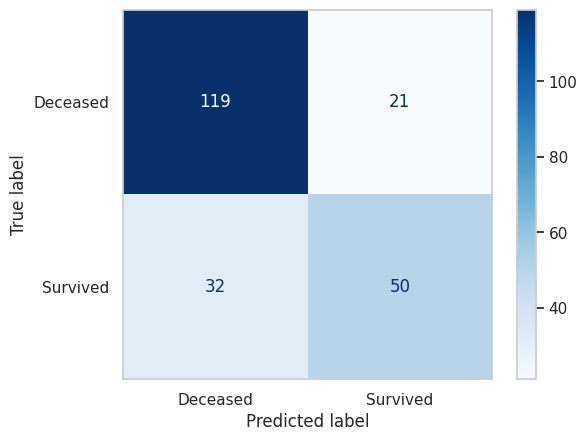

In [10]:
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap='Blues', display_labels=['Deceased', 'Survived'])
plt.grid(False)
plt.show()

# problem 1:
Explain precision, recall, and f1 score. Be clear and precise about what each one measures.   

Write your answer here.

# problem 2:
Look at the classification report for our model. Explain what the classification report values mean in terms of our model's performance.

Write your answer here.

# problem 3
Write code to find the best model with only four features.

In [11]:
# enter and test your code here


## problem 4
Explain your solution to problem 3. What did you find, how did you determine it is the best solution?

Write your answer here.